<a href="https://colab.research.google.com/github/GroupQ-Assignment-DataScience/GroupQ_Assignment_RMD/blob/main/Edward.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
from matplotlib import pyplot as plt
from sklearn import preprocessing

In [50]:
import pandas as pd
df = pd.read_csv('/content/dataset_C_training.csv')
df1 = pd.read_csv('/content/dataset_C_testing.csv')

In [51]:
df.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [64]:
# Basic Dataset Information
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (4756, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   respondent_id                 4756 non-null   int64  
 1   covid_concern                 4744 non-null   float64
 2   covid_knowledge               4729 non-null   float64
 3   behavioral_antiviral_meds     4742 non-null   float64
 4   behavioral_avoidance          4729 non-null   float64
 5   behavioral_face_mask          4754 non-null   float64
 6   behavioral_wash_hands         4747 non-null   float64
 7   behavioral_large_gatherings   4746 non-null   float64
 8   behavioral_outside_home       4742 non-null   float64
 9   behavioral_touch_face         4735 non-null   float64
 10  chronic_med_condition         4587 non-null   float64
 11  child_under_6_months          4621 non-null   float64
 12  health_worker                 462

# Pre-Processing

In [65]:
# STEP 4: Check Missing Values

missing_values = df.isnull().sum()

# Show columns with missing values
missing_values[missing_values > 0].sort_values(ascending=False)

,0
employment_sector,2330
health_insurance,1908
income_poverty,748
rent_or_own,329
employment_status,238
marital_status,231
education,228
chronic_med_condition,169
child_under_6_months,135
health_worker,132


In [66]:
# STEP 5: Calculate Missing Value Percentage

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percent
})

missing_report[missing_report['Missing Values'] > 0]\
.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
employment_sector,2330,48.990749
health_insurance,1908,40.117746
income_poverty,748,15.727502
rent_or_own,329,6.917578
employment_status,238,5.004205
marital_status,231,4.857023
education,228,4.793944
chronic_med_condition,169,3.553406
child_under_6_months,135,2.838520
health_worker,132,2.775442


In [52]:
# Install H20AutoML (only need to do this once)
!pip install h2o

# Import packages
import h2o
from h2o.automl import H2OAutoML

# Start the H2O cluster (locally)
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,44 mins 03 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,"14 days, 2 hours and 58 minutes"
H2O_cluster_name:,H2O_from_python_unknownUser_3vliw2
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.127 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [53]:
# Define the target variable (i.e. "response") and features (i.e. "predictors") for H20AutoML
response = 'covid_vaccine'
predictors = list(df.drop('covid_vaccine', axis=1).columns)

# Convert from a pandas dataframe to an h20 frame
hf = h2o.H2OFrame(df)

# Convert target column to categorical, as this is a binary classification problem
hf['covid_vaccine'] = hf['covid_vaccine'].asfactor()

# Split the data into training and testing sets using the H20 split_frame() method
train, test = hf.split_frame(seed=1, ratios=[0.75])

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [54]:
# Set-up and train the models
aml = H2OAutoML(max_runtime_secs=120, seed=1, include_algos=["GLM", "DRF", "XGBoost"])
aml.train(x=predictors, y=response, training_frame=train)

# Turn off default printed output
h2o.display.toggle_user_tips()

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


In [55]:
# Show leaderboard & performance information
aml.explain(test, include_explanations=["leaderboard"]);

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
XGBoost_grid_1_AutoML_3_20260605_124012_model_9,0.857981,0.436041,0.763665,0.205047,0.371786,0.138225,870,0.009187,XGBoost
XGBoost_grid_1_AutoML_3_20260605_124012_model_11,0.857184,0.437154,0.774044,0.20941,0.371198,0.137788,1541,0.009264,XGBoost
XGBoost_3_AutoML_3_20260605_124012,0.852352,0.450119,0.752071,0.220807,0.378058,0.142928,765,0.009516,XGBoost
XGBoost_grid_1_AutoML_3_20260605_124012_model_2,0.851511,0.450196,0.757612,0.220852,0.37799,0.142876,968,0.012132,XGBoost
XGBoost_grid_1_AutoML_3_20260605_124012_model_7,0.849853,0.447242,0.759508,0.220996,0.375701,0.141151,1276,0.011059,XGBoost
XGBoost_grid_1_AutoML_3_20260605_124012_model_5,0.848835,0.453043,0.757622,0.218889,0.379163,0.143765,1210,0.010491,XGBoost
XGBoost_grid_1_AutoML_3_20260605_124012_model_1,0.848723,0.457662,0.74374,0.224139,0.380552,0.14482,846,0.011228,XGBoost
XGBoost_grid_1_AutoML_3_20260605_124012_model_12,0.848207,0.446258,0.762446,0.218227,0.377162,0.142251,451,0.008804,XGBoost
DRF_1_AutoML_3_20260605_124012,0.848043,0.446797,0.758916,0.220325,0.378821,0.143505,1248,0.033282,DRF
XGBoost_1_AutoML_3_20260605_124012,0.847736,0.45869,0.742466,0.223599,0.380703,0.144934,875,0.009811,XGBoost


# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

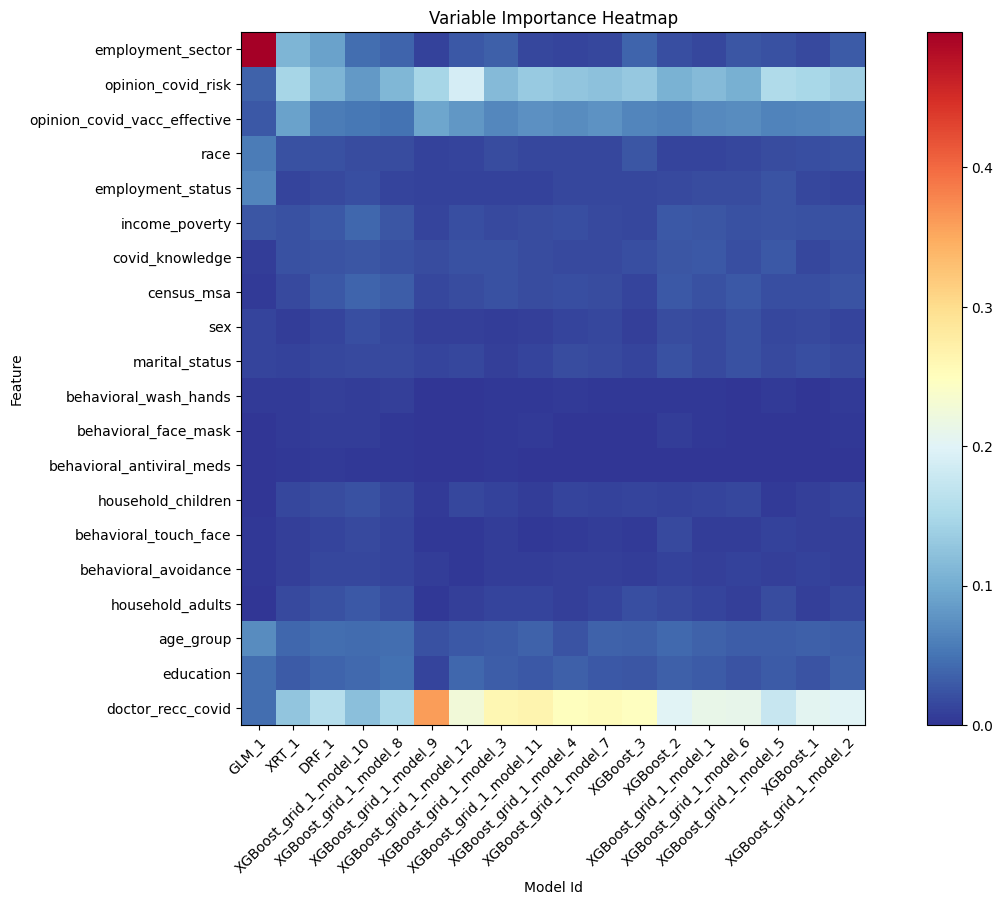

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

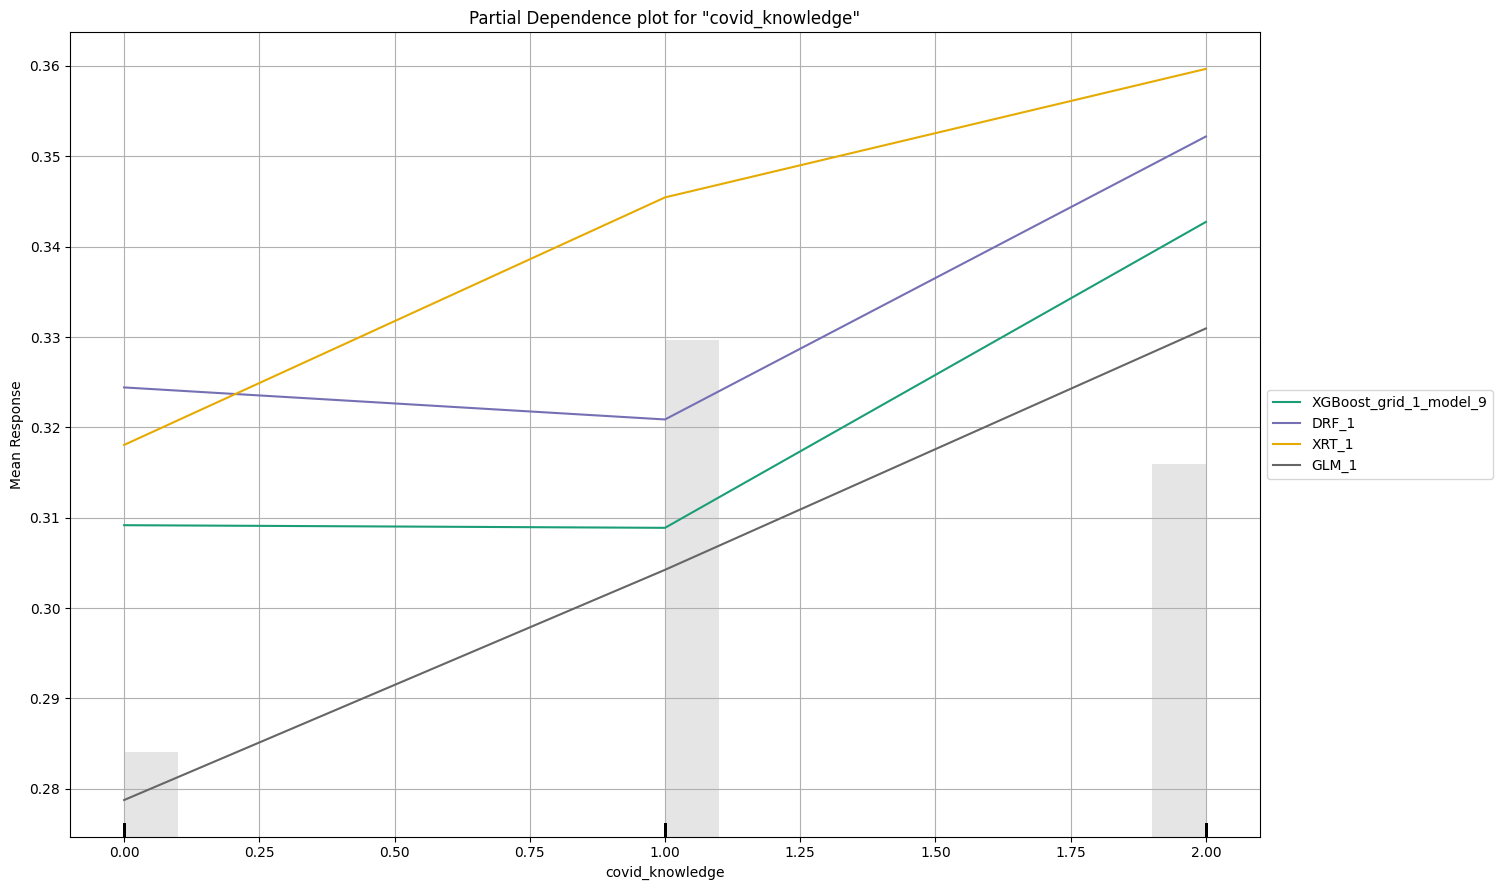

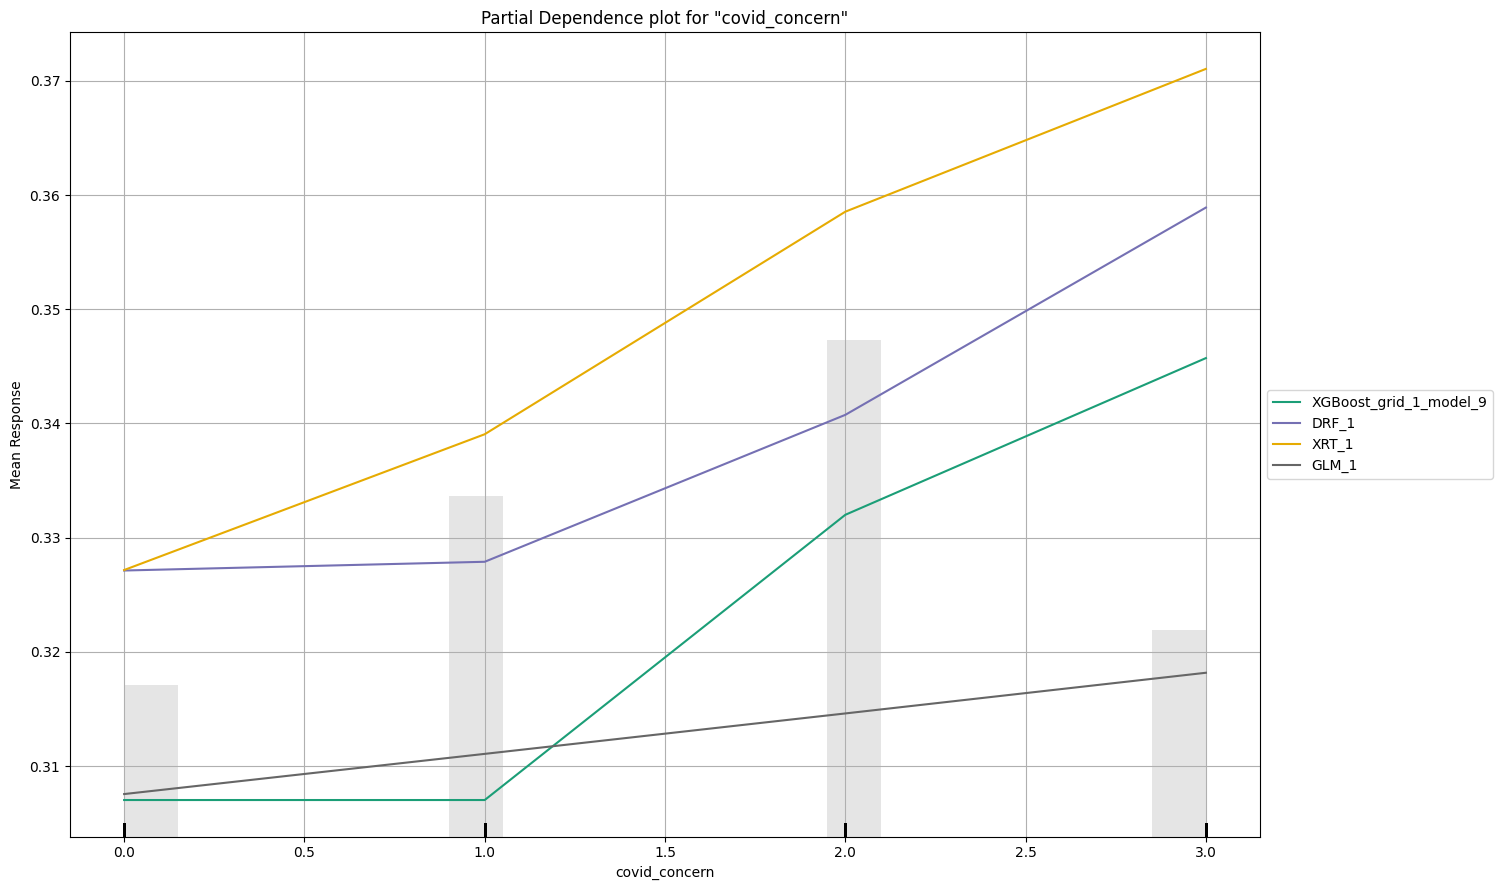

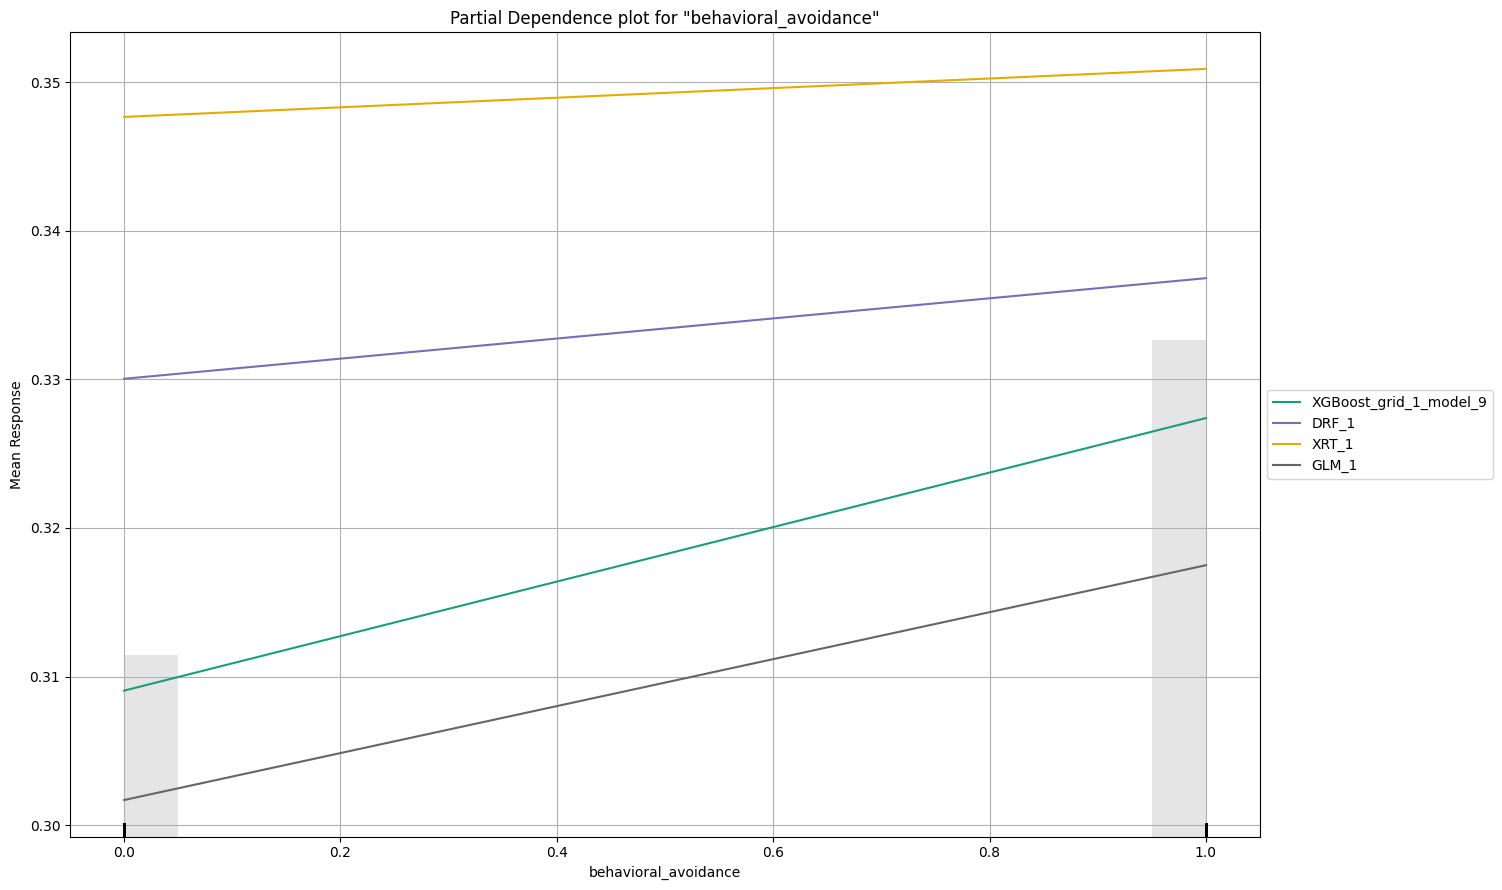

In [56]:
# Plot XAI information
aml.explain(test, include_explanations=["varimp_heatmap", "pdp"], \
            columns = ["covid_knowledge", "covid_concern", "behavioral_avoidance"]);

In [57]:
best_model = aml.leader
predictions = best_model.predict(test)

# Display predictions (first 5 rows)
print("Predictions:")
predictions.head()

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Predictions:


predict,p0,p1
0,0.948956,0.0510437
1,0.495895,0.504105
0,0.867009,0.132991
0,0.874319,0.125681
0,0.926646,0.0733542
0,0.956036,0.0439639
1,0.555417,0.444583
1,0.378396,0.621604
0,0.971343,0.0286567
0,0.819555,0.180445


In [58]:
print("Model performance on test set:")
performance = best_model.model_performance(test)
print(performance)

Model performance on test set:
ModelMetricsBinomial: xgboost
** Reported on test data. **

MSE: 0.13822494169661814
RMSE: 0.37178615049059877
LogLoss: 0.4360412413243884
Mean Per-Class Error: 0.20504697400043698
AUC: 0.8579807605803955
AUCPR: 0.7636645303279572
Gini: 0.715961521160791

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.3385191410779953
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      646  136  0.1739   (136.0/782.0)
1      94   304  0.2362   (94.0/398.0)
Total  740  440  0.1949   (230.0/1180.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.338519     0.725537  210
max f2                       0.176592     0.785519  281
max f0point5                 0.558119     0.733249  140
max accuracy                 0.458512     0.808475  171
max precision                0.920024     0.92

In [59]:
print(f"AUC: {performance.auc()}")
print(f"F1 Score: {performance.F1()}")
print("Confusion Matrix:")
print(performance.confusion_matrix())

AUC: 0.8579807605803955
F1 Score: [[0.3385191410779953, 0.7255369928400955]]
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.3385191410779953
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      646  136  0.1739   (136.0/782.0)
1      94   304  0.2362   (94.0/398.0)
Total  740  440  0.1949   (230.0/1180.0)


In [63]:
leaderboard_df = aml.leaderboard.as_data_frame()
display(leaderboard_df[['model_id', 'auc', 'logloss']].head(5))

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,auc,logloss
0,XGBoost_grid_1_AutoML_3_20260605_124012_model_9,0.855760,0.430895
1,XGBoost_grid_1_AutoML_3_20260605_124012_model_2,0.854408,0.435627
2,XGBoost_grid_1_AutoML_3_20260605_124012_model_5,0.852673,0.439731
3,DRF_1_AutoML_3_20260605_124012,0.851206,0.440459
4,XGBoost_grid_1_AutoML_3_20260605_124012_model_7,0.850270,0.440263


### Evaluating Top 5 Models on the Test Set

In [61]:
top_5_model_ids = leaderboard_df.head(5)['model_id'].tolist()

print("Evaluating top 5 models:")
for model_id in top_5_model_ids:
    print(f"\n--- Model: {model_id} ---")
    model = h2o.get_model(model_id)

    # Make predictions on the test set
    predictions = model.predict(test)
    print("Predictions (first 5 rows):")
    predictions.head()

    # Get and print model performance
    performance = model.model_performance(test)
    print("\nModel Performance on Test Set:")
    print(f"AUC: {performance.auc()}")
    print(f"F1 Score: {performance.F1()[0][1]}") # F1 for positive class
    print("Confusion Matrix:")
    print(performance.confusion_matrix())

Evaluating top 5 models:

--- Model: XGBoost_grid_1_AutoML_3_20260605_124012_model_9 ---
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Predictions (first 5 rows):

Model Performance on Test Set:
AUC: 0.8579807605803955
F1 Score: 0.7255369928400955
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.3385191410779953
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      646  136  0.1739   (136.0/782.0)
1      94   304  0.2362   (94.0/398.0)
Total  740  440  0.1949   (230.0/1180.0)

--- Model: XGBoost_grid_1_AutoML_3_20260605_124012_model_2 ---
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Predictions (first 5 rows):

Model Performance on Test Set:
AUC: 0.8515113932835533
F1 Score: 0.7056019070321812
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.32114945352077484
       0    1    Error    Rate
-----  ---  ---  -------  -

### Visualizing Model Performance

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

model_performance_data = []

for model_id in top_5_model_ids:
    model = h2o.get_model(model_id)
    performance = model.model_performance(test)

    model_performance_data.append({
        'model_id': model_id,
        'auc': performance.auc(),
        'f1_score': performance.F1()[0][1] # F1 for positive class
    })

performance_df = pd.DataFrame(model_performance_data)

display(performance_df)

,model_id,auc,f1_score
0,XGBoost_grid_1_AutoML_3_20260605_124012_model_9,0.857981,0.725537
1,XGBoost_grid_1_AutoML_3_20260605_124012_model_2,0.851511,0.705602
2,XGBoost_grid_1_AutoML_3_20260605_124012_model_5,0.848835,0.708434
3,DRF_1_AutoML_3_20260605_124012,0.848043,0.705744
4,XGBoost_grid_1_AutoML_3_20260605_124012_model_7,0.849853,0.708010


/tmp/ipykernel_7045/289384496.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_id', y='auc', data=performance_df, palette='viridis')


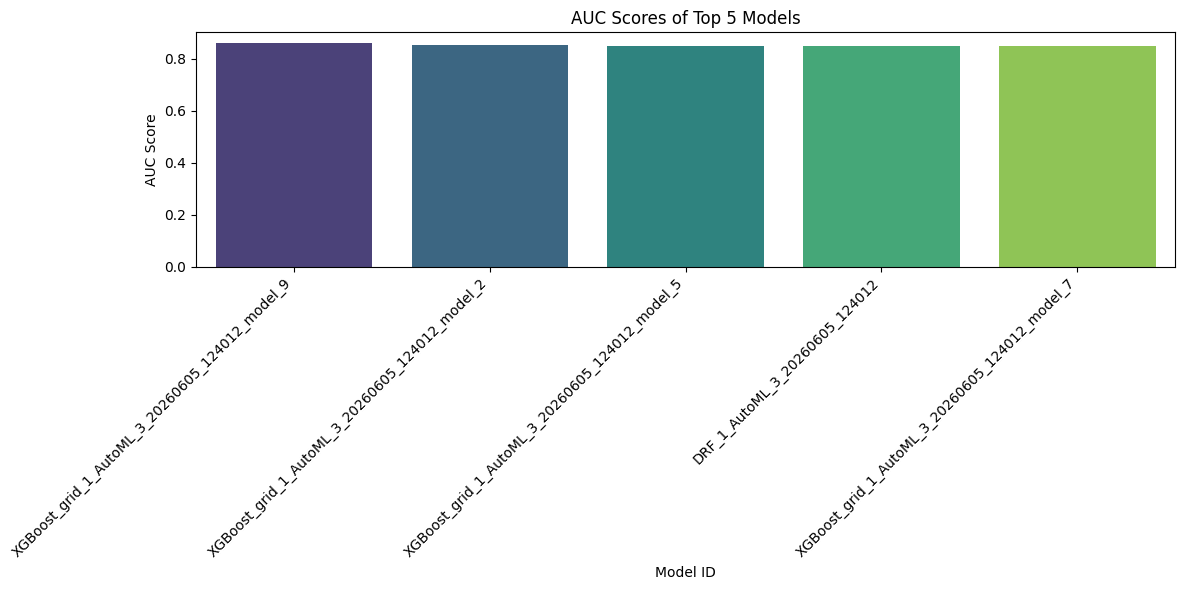

In [68]:
# Plot AUC scores
plt.figure(figsize=(12, 6))
sns.barplot(x='model_id', y='auc', data=performance_df, palette='viridis')
plt.title('AUC Scores of Top 5 Models')
plt.xlabel('Model ID')
plt.ylabel('AUC Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_7045/4162230465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_id', y='f1_score', data=performance_df, palette='magma')


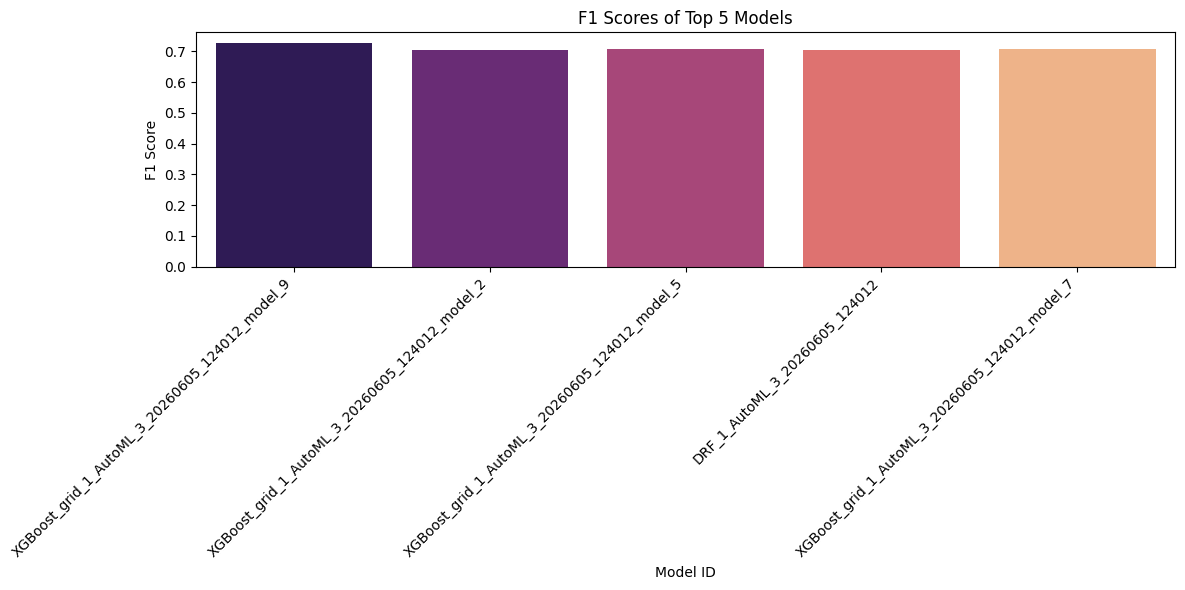

In [69]:
# Plot F1 scores
plt.figure(figsize=(12, 6))
sns.barplot(x='model_id', y='f1_score', data=performance_df, palette='magma')
plt.title('F1 Scores of Top 5 Models')
plt.xlabel('Model ID')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()